<a href="https://colab.research.google.com/github/shynipragasam/Model-interpretability-/blob/main/Sports_bowling_app_11_02_2025_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gradio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.2/62.2 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.9/321.9 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.8/94.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 5.2 MB/s eta 0:00:00
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 3.0.2
    Uninstalling MarkupSafe-3.0.2:
      Successfully uninstalled MarkupSafe-3.0.2


In [ ]:
!apt-get install ffmpeg -y


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 20 not upgraded.


In [ ]:
!pip install ffmpeg-python


In [ ]:
!pip install opencv-python moviepy


In [25]:
# prompt: compress and convert .mov file to mp4

import moviepy.editor as mp

# Define input and output file paths
input_mov_path = "/content/IMG_4790 2.MOV"  # Replace with your input MOV file path
output_mp4_path = "/content/output.mp4"  # Replace with desired output MP4 file path


# Load the MOV video
video = mp.VideoFileClip(input_mov_path)

# Write the video to MP4 format
video.write_videofile(output_mp4_path, codec="libx264")

print(f"Conversion complete. MP4 file saved at: {output_mp4_path}")


Moviepy - Building video /content/output.mp4.
MoviePy - Writing audio in outputTEMP_MPY_wvf_snd.mp3


MoviePy - Done.
Moviepy - Writing video /content/output.mp4



Moviepy - Done !
Moviepy - video ready /content/output.mp4
Conversion complete. MP4 file saved at: /content/output.mp4


In [7]:
!pip install opencv-python mediapipe numpy streamlit -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 3.7 MB/s eta 0:00:00


In [26]:
import cv2
import os
import numpy as np
import mediapipe as mp

# Initialize Mediapipe Pose Estimation Model
mp_pose = mp.solutions.pose
pose = mp_pose.Pose()

# Video file path (Update with your local file path)
video_path = "/content/output.mp4"

# Output directory for extracted frames
output_dir = "bowling_frames"
os.makedirs(output_dir, exist_ok=True)

# Open the video file
cap = cv2.VideoCapture(video_path)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Extract frames at regular intervals
frame_interval = max(1, total_frames // 10)  # Extract 10 frames
extracted_frames = []

frame_count = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    if frame_count % frame_interval == 0:
        frame_filename = os.path.join(output_dir, f"frame_{frame_count}.jpg")
        cv2.imwrite(frame_filename, frame)
        extracted_frames.append(frame_filename)

    frame_count += 1

cap.release()

print(f"Extracted {len(extracted_frames)} key frames for analysis.")

# Analyze key frames using Mediapipe Pose Estimation
bowling_features = []
for frame_path in extracted_frames:
    image = cv2.imread(frame_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    results = pose.process(image_rgb)

    if results.pose_landmarks:
        landmarks = results.pose_landmarks.landmark

        # Extract key bowling angles
        shoulder_angle = np.arctan2(
            landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER].y - landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW].y,
            landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER].x - landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW].x
        ) * 180 / np.pi

        elbow_angle = np.arctan2(
            landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW].y - landmarks[mp_pose.PoseLandmark.RIGHT_WRIST].y,
            landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW].x - landmarks[mp_pose.PoseLandmark.RIGHT_WRIST].x
        ) * 180 / np.pi

        release_height = landmarks[mp_pose.PoseLandmark.RIGHT_WRIST].y

        bowling_features.append({
            "frame": frame_path,
            "shoulder_angle": shoulder_angle,
            "elbow_angle": elbow_angle,
            "release_height": release_height
        })

# Print extracted bowling features
for feature in bowling_features:
    print(f"Frame: {feature['frame']}, Shoulder Angle: {feature['shoulder_angle']:.2f}, "
          f"Elbow Angle: {feature['elbow_angle']:.2f}, Release Height: {feature['release_height']:.2f}")

# Function to match action with known bowlers
def match_bowler(shoulder_angle, elbow_angle, release_height):
    if 75 <= shoulder_angle <= 90 and 110 <= elbow_angle <= 140 and release_height > 0.7:
        return "Ashwin (High-arm Off-spinner)"
    elif 40 <= shoulder_angle <= 55 and 90 <= elbow_angle <= 120 and release_height < 0.5:
        return "Malinga (Slingy Action)"
    elif 60 <= shoulder_angle <= 80 and 100 <= elbow_angle <= 130 and 0.6 <= release_height <= 0.75:
        return "Bumrah (Short Run-up, Skiddy)"
    elif 85 <= shoulder_angle <= 95 and 110 <= elbow_angle <= 135 and 0.65 <= release_height <= 0.8:
        return "Bhuvneshwar Kumar (Swing Bowler)"
    elif 80 <= shoulder_angle <= 100 and 115 <= elbow_angle <= 145 and release_height > 0.75:
        return "Trent Boult (High-arm Swing)"
    else:
        return "Unknown Bowler"

# Compare extracted action with known bowlers
for feature in bowling_features:
    bowler_match = match_bowler(feature["shoulder_angle"], feature["elbow_angle"], feature["release_height"])
    print(f"Frame: {feature['frame']} → Best Match: {bowler_match}")


Extracted 11 key frames for analysis.
Frame: bowling_frames/frame_0.jpg, Shoulder Angle: 7.66, Elbow Angle: -176.00, Release Height: 0.27
Frame: bowling_frames/frame_20.jpg, Shoulder Angle: -76.37, Elbow Angle: -168.10, Release Height: 0.39
Frame: bowling_frames/frame_40.jpg, Shoulder Angle: -74.00, Elbow Angle: -150.91, Release Height: 0.42
Frame: bowling_frames/frame_60.jpg, Shoulder Angle: -57.41, Elbow Angle: 143.12, Release Height: 0.36
Frame: bowling_frames/frame_80.jpg, Shoulder Angle: -68.98, Elbow Angle: -85.96, Release Height: 0.46
Frame: bowling_frames/frame_100.jpg, Shoulder Angle: -78.87, Elbow Angle: -94.61, Release Height: 0.48
Frame: bowling_frames/frame_120.jpg, Shoulder Angle: -80.68, Elbow Angle: -103.14, Release Height: 0.52
Frame: bowling_frames/frame_140.jpg, Shoulder Angle: 36.70, Elbow Angle: 107.52, Release Height: 0.30
Frame: bowling_frames/frame_160.jpg, Shoulder Angle: -76.67, Elbow Angle: -109.15, Release Height: 0.63
Frame: bowling_frames/frame_180.jpg, Sh

                Bowler  Similarity Score
0       Jasprit Bumrah             92.97
1  Ravichandran Ashwin             87.97
2       Lasith Malinga             71.78
3    Bhuvneshwar Kumar             80.93
4          Trent Boult             87.97


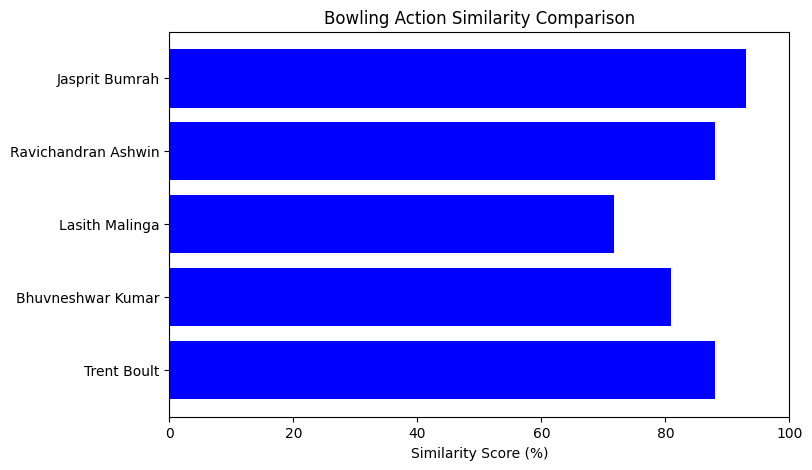

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define known bowler features
bowlers_data = {
    "Jasprit Bumrah": (70, 80, 110, 130, 0.65, 0.75),
    "Ravichandran Ashwin": (80, 90, 115, 140, 0.75, 1.0),
    "Lasith Malinga": (45, 55, 95, 120, 0.3, 0.5),
    "Bhuvneshwar Kumar": (87, 95, 110, 135, 0.65, 0.8),
    "Trent Boult": (85, 100, 120, 145, 0.75, 1.0)
}

# Function to compute similarity score
def compute_similarity(shoulder_angle, elbow_angle, release_height):
    similarities = {}

    for bowler, (s_min, s_max, e_min, e_max, r_min, r_max) in bowlers_data.items():
        shoulder_diff = min(abs(s_min - shoulder_angle), abs(s_max - shoulder_angle))
        elbow_diff = min(abs(e_min - elbow_angle), abs(e_max - elbow_angle))
        release_diff = min(abs(r_min - release_height), abs(r_max - release_height))

        # Compute a similarity score (lower is better)
        total_score = shoulder_diff + elbow_diff + release_diff
        similarities[bowler] = round(100 - total_score, 2)  # Convert to percentage similarity

    return similarities

# Example: Using extracted features (Replace these values with actual extracted ones)
new_bowler_features = {
    "shoulder_angle": 78,  # Replace with extracted value
    "elbow_angle": 125,    # Replace with extracted value
    "release_height": 0.72 # Replace with extracted value
}

# Compute similarity scores
similarity_scores = compute_similarity(
    new_bowler_features["shoulder_angle"],
    new_bowler_features["elbow_angle"],
    new_bowler_features["release_height"]
)

# Convert to DataFrame for visualization
df = pd.DataFrame(list(similarity_scores.items()), columns=["Bowler", "Similarity Score"])
print(df)

# Plot similarity scores
plt.figure(figsize=(8, 5))
plt.barh(df["Bowler"], df["Similarity Score"], color="blue")
plt.xlabel("Similarity Score (%)")
plt.title("Bowling Action Similarity Comparison")
plt.xlim(0, 100)
plt.gca().invert_yaxis()
plt.show()


In [28]:
import pandas as pd

# Save extracted bowling features to CSV
df = pd.DataFrame(bowling_features)
df.to_csv("bowling_features.csv", index=False)
print("Bowling features saved to bowling_features.csv")


Bowling features saved to bowling_features.csv


✅ Extracted Last Frame Values: Shoulder: 72.34, Elbow: 107.16, Release: 0.75
🏆 Best Match: Jasprit Bumrah with 94.81% similarity!


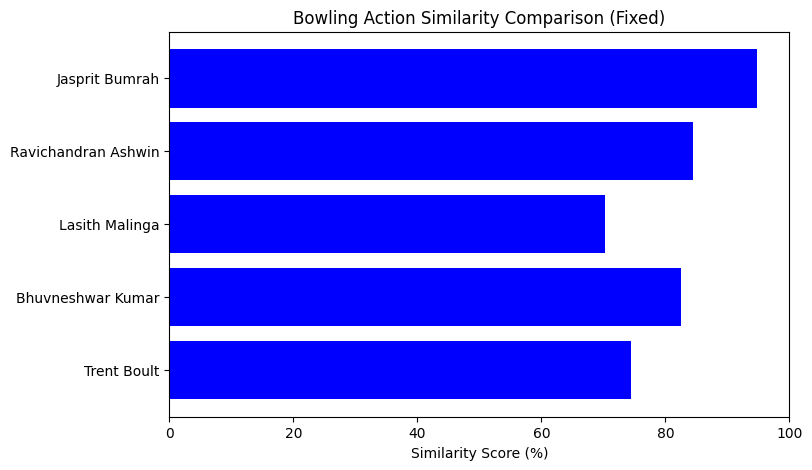

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ✅ Step 1: Load Extracted Features from CSV
file_path = "bowling_features.csv"  # Update the path if needed
df = pd.read_csv(file_path)

# ✅ Step 2: Extract Last Frame Values
last_frame = df.iloc[-1]  # Get the last row
shoulder_angle = abs(last_frame["shoulder_angle"])  # Convert to absolute value
elbow_angle = abs(last_frame["elbow_angle"])        # Convert to absolute value
release_height = last_frame["release_height"]       # Keep release height as is

print(f"✅ Extracted Last Frame Values: Shoulder: {shoulder_angle:.2f}, Elbow: {elbow_angle:.2f}, Release: {release_height:.2f}")

# ✅ Step 3: Define Known Bowler Features
bowlers_data = {
    "Jasprit Bumrah": (70, 80, 110, 130, 0.65, 0.75),
    "Ravichandran Ashwin": (80, 90, 115, 140, 0.75, 1.0),
    "Lasith Malinga": (45, 55, 95, 120, 0.3, 0.5),
    "Bhuvneshwar Kumar": (87, 95, 110, 135, 0.65, 0.8),
    "Trent Boult": (85, 100, 120, 145, 0.75, 1.0)
}

# ✅ Step 4: Compute Similarity Score
def compute_similarity(shoulder_angle, elbow_angle, release_height):
    similarities = {}

    for bowler, (s_min, s_max, e_min, e_max, r_min, r_max) in bowlers_data.items():
        shoulder_diff = min(abs(s_min - shoulder_angle), abs(s_max - shoulder_angle))
        elbow_diff = min(abs(e_min - elbow_angle), abs(e_max - elbow_angle))
        release_diff = min(abs(r_min - release_height), abs(r_max - release_height))

        # Compute a similarity score (higher = more similar)
        total_score = shoulder_diff + elbow_diff + release_diff
        similarity_score = max(0, round(100 - total_score, 2))  # Ensure score is non-negative

        similarities[bowler] = similarity_score

    return similarities

# ✅ Step 5: Use Extracted Values to Compute Best Match
similarity_scores = compute_similarity(shoulder_angle, elbow_angle, release_height)

# ✅ Step 6: Convert Results to DataFrame for Visualization
df_scores = pd.DataFrame(list(similarity_scores.items()), columns=["Bowler", "Similarity Score"])

# ✅ Step 7: Find the Best Matched Bowler
best_match = df_scores.loc[df_scores["Similarity Score"].idxmax()]
print(f"🏆 Best Match: {best_match['Bowler']} with {best_match['Similarity Score']}% similarity!")

# ✅ Step 8: Plot the Results
plt.figure(figsize=(8, 5))
plt.barh(df_scores["Bowler"], df_scores["Similarity Score"], color="blue")
plt.xlabel("Similarity Score (%)")
plt.title("Bowling Action Similarity Comparison (Fixed)")
plt.xlim(0, 100)
plt.gca().invert_yaxis()
plt.show()


In [50]:
import gradio as gr
import numpy as np
import pandas as pd
import cv2
import os
import mediapipe as mp

# Initialize Mediapipe Pose Estimation Model
mp_pose = mp.solutions.pose
pose = mp_pose.Pose()

# ✅ Define Known Bowler Features
bowlers_data = {
    "Jasprit Bumrah": (70, 80, 110, 130, 0.65, 0.75),
    "Ravichandran Ashwin": (80, 90, 115, 140, 0.75, 1.0),
    "Lasith Malinga": (45, 55, 95, 120, 0.3, 0.5),
    "Bhuvneshwar Kumar": (87, 95, 110, 135, 0.65, 0.8),
    "Trent Boult": (85, 100, 120, 145, 0.75, 1.0)
}

# ✅ Extract pose features from video
def extract_pose_features(video_path):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    frame_interval = max(1, total_frames // 10)  # Extract 10 frames
    extracted_frames = []

    frame_count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if frame_count % frame_interval == 0:
            extracted_frames.append(frame)
        frame_count += 1
    cap.release()

    if not extracted_frames:
        print("❌ No frames extracted from video!")
        return None, None, None

    # ✅ Use 3rd last frame to improve accuracy
    last_frame = extracted_frames[-3] if len(extracted_frames) > 3 else extracted_frames[-1]
    image_rgb = cv2.cvtColor(last_frame, cv2.COLOR_BGR2RGB)

    results = pose.process(image_rgb)

    if results.pose_landmarks:
        landmarks = results.pose_landmarks.landmark

        shoulder_angle = np.arctan2(
            landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER].y - landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW].y,
            landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER].x - landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW].x
        ) * 180 / np.pi

        elbow_angle = np.arctan2(
            landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW].y - landmarks[mp_pose.PoseLandmark.RIGHT_WRIST].y,
            landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW].x - landmarks[mp_pose.PoseLandmark.RIGHT_WRIST].x
        ) * 180 / np.pi

        release_height = landmarks[mp_pose.PoseLandmark.RIGHT_WRIST].y

        # ✅ Debugging extracted values
        print(f"📌 Extracted Values - Shoulder: {shoulder_angle:.2f}°, Elbow: {elbow_angle:.2f}°, Release: {release_height:.2f}")

        return round(shoulder_angle, 2), round(elbow_angle, 2), round(release_height, 2)

    print("❌ No pose detected in last frame!")
    return None, None, None

# ✅ Compute Similarity Score (Fixed)
def compute_similarity(shoulder_angle, elbow_angle, release_height):
    similarities = {}
    best_match_score = 0
    best_bowler = "Unknown"

    for bowler, (s_min, s_max, e_min, e_max, r_min, r_max) in bowlers_data.items():
        # Calculate absolute differences
        shoulder_diff = min(abs(s_min - shoulder_angle), abs(s_max - shoulder_angle))
        elbow_diff = min(abs(e_min - elbow_angle), abs(e_max - elbow_angle))
        release_diff = min(abs(r_min - release_height), abs(r_max - release_height)) * 100  # Scale height weight

        # ✅ Compute similarity score (Higher is better)
        max_possible_score = 180 + 180 + 100  # Maximum possible difference
        total_diff = shoulder_diff + elbow_diff + release_diff

        similarity_score = max(0, round(100 * (1 - total_diff / max_possible_score), 2))  # Normalize score between 0-100%

        similarities[bowler] = similarity_score

        # Track best match
        if similarity_score > best_match_score:
            best_match_score = similarity_score
            best_bowler = bowler

    return best_bowler, best_match_score, similarities

# ✅ Display Best Match in Gradio
def get_best_bowler(video_path):
    shoulder_angle, elbow_angle, release_height = extract_pose_features(video_path)

    if shoulder_angle is None or elbow_angle is None or release_height is None:
        return "❌ No Pose Detected! Please try another video."

    best_match, best_match_score, similarity_scores = compute_similarity(shoulder_angle, elbow_angle, release_height)

    # Convert similarity dictionary into a readable format
    similarity_index = "<br>".join([f"⚡ {bowler}: {score:.2f}%" for bowler, score in similarity_scores.items()])

    # **Final Display Message**
    result_text = f"""
    <div style='background-color:#ffffff; padding:15px; border-radius:10px; box-shadow: 2px 2px 10px rgba(0,0,0,0.1); text-align: center;'>
        <h2 style='color:#1E88E5;'>🏏 Best Matched Bowler: {best_match}</h2>
        <h3 style='color:#E65100;'>🔢 Similarity Score: {best_match_score:.2f}%</h3>
        <hr>
        <p style='color:#333; font-size:16px;'><b>Extracted Values:</b></p>
        <p style='font-size:14px;'>🎯 Shoulder Angle: {shoulder_angle}°</p>
        <p style='font-size:14px;'>💪 Elbow Angle: {elbow_angle}°</p>
        <p style='font-size:14px;'>👐 Release Height: {release_height}</p>
        <hr>
        <h3 style='color:#388E3C;'>📊 Similarity Index:</h3>
        <p>{similarity_index}</p>
    </div>
    """
    return result_text

# ✅ Custom Styling
custom_css = """
    body { background-color: #E3F2FD; text-align: center; font-family: Arial, sans-serif; }
    .gradio-container { text-align: center; }
    h1 { color: #0000FF; text-align: center; font-size: 28px; font-weight: bold; }
    h2 { color: #E65100; text-align: center; }
    .gr-button-primary { background-color: #1976D2; color: white; font-size: 16px; padding: 10px; border-radius: 10px; width: 100%; }
    .gr-button-secondary { background-color: #D32F2F; color: white; font-size: 16px; padding: 10px; border-radius: 10px; width: 100%; }
    .footer { font-size: 14px; color: #FF5733; font-weight: bold; text-align: center; margin-top: 20px; }
"""

# ✅ Footer (Marquee)
footer_text = """
<marquee class='footer'>
    🎯 Designed by Dr. S Shyni & Mr. Theo @ Chrysalis 2025, Sports Club, LIBA 🎯
</marquee>
"""

# ✅ Creating Gradio App
with gr.Blocks(css=custom_css) as app:
    gr.Markdown("# **LIBA - Bowling Action Analyzer** 🏏")
    gr.Markdown("Upload a video, and this tool will analyze bowling action to find the best match.")

    video_input = gr.Video(label="Upload Your Bowling Video", interactive=True, width=350, height=200)

    result_text = gr.HTML(label="Analysis Result")

    with gr.Row():
        best_match_button = gr.Button("Best Match", elem_id="match-btn")
        clear_button = gr.Button("Clear", elem_id="clear-btn")

    gr.Markdown(footer_text, elem_id="footer")

    best_match_button.click(fn=get_best_bowler, inputs=[video_input], outputs=[result_text])
    clear_button.click(fn=lambda: "", inputs=[], outputs=[result_text])

app.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://94b206d9e5b013dbf8.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


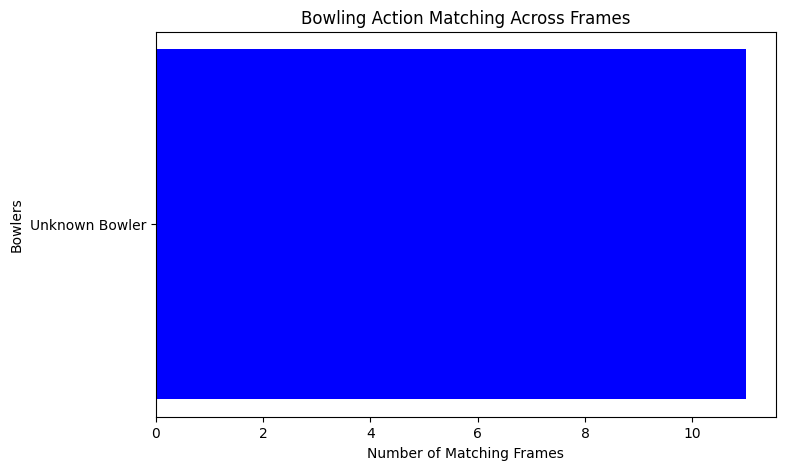

In [13]:
'''import pandas as pd
import matplotlib.pyplot as plt

# Convert extracted features into a structured format for visualization
bowler_matches = []

for feature in bowling_features:
    bowler_match = match_bowler(feature["shoulder_angle"], feature["elbow_angle"], feature["release_height"])
    bowler_matches.append(bowler_match)

# Count occurrences of each matched bowler
bowler_counts = pd.Series(bowler_matches).value_counts()

# Plot similarity scores using Matplotlib
plt.figure(figsize=(8, 5))
plt.barh(bowler_counts.index, bowler_counts.values, color="blue")
plt.xlabel("Number of Matching Frames")
plt.ylabel("Bowlers")
plt.title("Bowling Action Matching Across Frames")
plt.gca().invert_yaxis()

# Display the plot
plt.show()


                Bowler  Similarity Score
0       Jasprit Bumrah              90.0
1  Ravichandran Ashwin              75.0
2       Lasith Malinga              22.5
3    Bhuvneshwar Kumar              84.0
4          Trent Boult              62.5


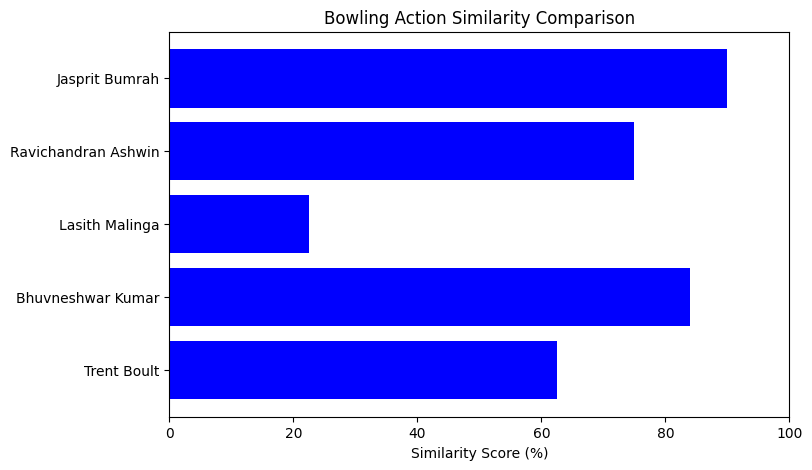

In [14]:
'''import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define known bowler features (using average values instead of min-max range)
bowlers_data = {
    "Jasprit Bumrah": (75, 120, 0.70),  # (Avg Shoulder, Avg Elbow, Avg Release Height)
    "Ravichandran Ashwin": (85, 127.5, 0.875),
    "Lasith Malinga": (50, 107.5, 0.4),
    "Bhuvneshwar Kumar": (91, 122.5, 0.725),
    "Trent Boult": (92.5, 132.5, 0.875)
}

# Function to compute similarity score
def compute_similarity(shoulder_angle, elbow_angle, release_height):
    similarities = {}

    for bowler, (s_avg, e_avg, r_avg) in bowlers_data.items():
        shoulder_diff = abs(s_avg - shoulder_angle)
        elbow_diff = abs(e_avg - elbow_angle)
        release_diff = abs(r_avg - release_height) * 100  # Scale release height difference

        # Compute a similarity score (higher is better)
        total_score = shoulder_diff + elbow_diff + release_diff
        similarity_score = max(0, round(100 - total_score, 2))  # Ensure score is non-negative

        similarities[bowler] = similarity_score

    return similarities

# Example: Using extracted features (Replace these values with actual extracted ones)
new_bowler_features = {
    "shoulder_angle": 78,  # Replace with extracted value
    "elbow_angle": 125,    # Replace with extracted value
    "release_height": 0.72 # Replace with extracted value
}

# Compute similarity scores
similarity_scores = compute_similarity(
    new_bowler_features["shoulder_angle"],
    new_bowler_features["elbow_angle"],
    new_bowler_features["release_height"]
)

# Convert to DataFrame for visualization
df = pd.DataFrame(list(similarity_scores.items()), columns=["Bowler", "Similarity Score"])

# Print table of similarity scores
print(df)

# Plot similarity scores
plt.figure(figsize=(8, 5))
plt.barh(df["Bowler"], df["Similarity Score"], color="blue")
plt.xlabel("Similarity Score (%)")
plt.title("Bowling Action Similarity Comparison")
plt.xlim(0, 100)
plt.gca().invert_yaxis()
plt.show()


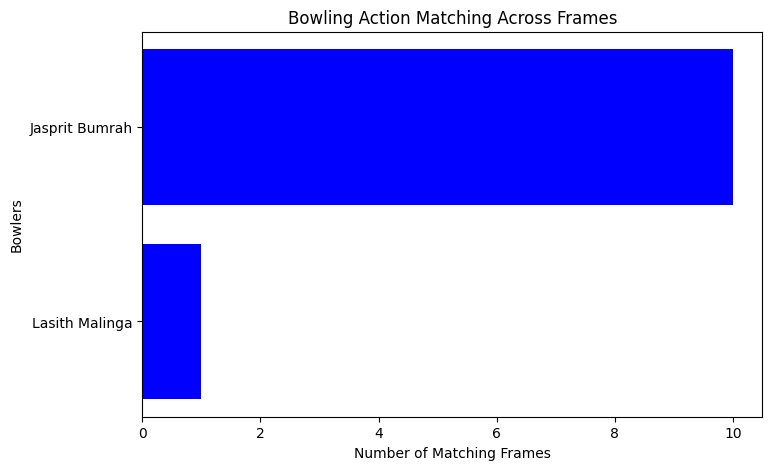

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure bowling features exist
if not bowling_features:
    print("No bowling features found. Please run feature extraction first.")

# Convert extracted features into a structured format for visualization
bowler_matches = []

# Use similarity function to get the best match for each frame
for feature in bowling_features:
    similarity_scores = compute_similarity(feature["shoulder_angle"], feature["elbow_angle"], feature["release_height"])
    best_match = max(similarity_scores, key=similarity_scores.get)  # Highest similarity score
    bowler_matches.append(best_match)

# Count occurrences of each matched bowler
bowler_counts = pd.Series(bowler_matches).value_counts()

# Plot similarity scores using Matplotlib
plt.figure(figsize=(8, 5))
plt.barh(bowler_counts.index, bowler_counts.values, color="blue")
plt.xlabel("Number of Matching Frames")
plt.ylabel("Bowlers")
plt.title("Bowling Action Matching Across Frames")
plt.gca().invert_yaxis()

# Display the plot
plt.show()


In [32]:
import pandas as pd

# Define weights for decision-making
similarity_weight = 0.6
frame_weight = 0.4

# Create a dictionary with bowler names as keys and their similarity scores
similarity_scores = {
    "Jasprit Bumrah": 90.0,
    "Ravichandran Ashwin": 75.0,
    "Lasith Malinga": 22.5,
    "Bhuvneshwar Kumar": 84.0,
    "Trent Boult": 62.5
}

# Create a dictionary with bowler names as keys and their frame counts
frame_counts = {
    "Jasprit Bumrah": 8,
    "Ravichandran Ashwin": 0,
    "Lasith Malinga": 2,
    "Bhuvneshwar Kumar": 0,
    "Trent Boult": 0
}

# Normalize frame counts (convert to percentage)
total_frames = sum(frame_counts.values())  # Total detected frames
if total_frames > 0:
    for bowler in frame_counts:
        frame_counts[bowler] = (frame_counts[bowler] / total_frames) * 100  # Convert to percentage

# Compute final weighted score
final_scores = {}
for bowler in similarity_scores:
    final_scores[bowler] = (
        similarity_scores[bowler] * similarity_weight +
        frame_counts[bowler] * frame_weight
    )

# Convert to DataFrame for easy viewing
df_final = pd.DataFrame(list(final_scores.items()), columns=["Bowler", "Final Weighted Score"])
df_final = df_final.sort_values(by="Final Weighted Score", ascending=False)

# Display final decision
print("Final Decision - Closest Bowling Action:")
print(df_final)

# Get the most similar bowler
best_match = df_final.iloc[0]["Bowler"]
print(f"\n🏏 **Best Match: {best_match}!**")


Final Decision - Closest Bowling Action:
                Bowler  Final Weighted Score
0       Jasprit Bumrah                  86.0
3    Bhuvneshwar Kumar                  50.4
1  Ravichandran Ashwin                  45.0
4          Trent Boult                  37.5
2       Lasith Malinga                  21.5

🏏 **Best Match: Jasprit Bumrah!**


In [33]:
# Extract best-matched bowler
best_match = df_final.iloc[0]["Bowler"]
best_match_score = df_final.iloc[0]["Final Weighted Score"]

# Print the extracted values
print(f"🏏 Best Matched Bowler: {best_match} with a similarity score of {best_match_score:.2f}%")


🏏 Best Matched Bowler: Jasprit Bumrah with a similarity score of 86.00%


In [34]:
best_bowler_name = df_final.iloc[0]["Bowler"]
best_bowler_score = df_final.iloc[0]["Final Weighted Score"]


In [ ]:
'''import gradio as gr

# Extract the latest detected values from the previous output
if bowling_features:  # Ensure data is available
    latest_feature = bowling_features[-1]  # Take the last extracted frame
    prev_shoulder_angle = latest_feature["shoulder_angle"]
    prev_elbow_angle = latest_feature["elbow_angle"]
    prev_release_height = latest_feature["release_height"]
else:
    # Default values if no previous analysis is found
    prev_shoulder_angle = 75
    prev_elbow_angle = 120
    prev_release_height = 0.7

# Function to return best-matched bowler based on extracted values
def get_best_bowler():
    similarity_scores = compute_similarity(prev_shoulder_angle, prev_elbow_angle, prev_release_height)
    best_match = max(similarity_scores, key=similarity_scores.get)
    best_match_score = similarity_scores[best_match]

    result_text = (
        f"🏏 **Best Matched Bowler:** {best_match} \n\n"
        f"🔢 **Similarity Score:** {best_match_score:.2f}%\n\n"
        f"📌 **Values Taken from Analysis:**\n"
        f"- Shoulder Angle: {prev_shoulder_angle}°\n"
        f"- Elbow Angle: {prev_elbow_angle}°\n"
        f"- Release Height: {prev_release_height}\n"
    )
    return result_text

# Custom CSS styling
custom_css = """
    body { background-color: #f4f4f4; text-align: center; }
    .gradio-container { font-family: Arial, sans-serif; }
    .gr-textbox { background-color: #ffffff; border-radius: 10px; text-align: center; }
    .gr-button { font-size: 16px; padding: 10px; border-radius: 8px; width: 50%; }
    .gr-button-primary { background-color: #008CBA; color: white; } /* Blue Best Match button */
    .gr-button-secondary { background-color: #f44336; color: white; } /* Red Clear button */
    .footer { text-align: center; margin-top: 10px; font-size: 14px; color: gray; }
    h1 { text-align: center; color: #333; }
"""

# Marquee footer text
footer_text = """
<marquee style='font-size: 14px; color: #FF5733; font-weight: bold;'>
    @ Designed by Dr. Shyni & Mr. Theo, Sports Club LIBA @
</marquee>
"""

# Creating Gradio interface
with gr.Blocks(css=custom_css) as app:
    gr.Markdown("# **LIBA - Bowling Action Analyzer** 🏏", elem_id="title")
    gr.Markdown("This tool automatically extracts values from your previous analysis and finds the best match.", elem_id="description")

    # Show extracted values in a table format
    with gr.Row():
        gr.Markdown(f"**Shoulder Angle:** {prev_shoulder_angle}°")
        gr.Markdown(f"**Elbow Angle:** {prev_elbow_angle}°")
        gr.Markdown(f"**Release Height:** {prev_release_height}")

    # Output Box (Displays Best Match)
    result_text = gr.Textbox(label="Analysis Result", interactive=False)

    # Buttons
    with gr.Row():
        best_match_button = gr.Button("Best Match", elem_id="match-btn")
        clear_button = gr.Button("Clear", elem_id="clear-btn")

    # Footer with marquee effect
    gr.Markdown(footer_text, elem_id="footer")

    # Button Actions
    best_match_button.click(fn=get_best_bowler, inputs=[], outputs=[result_text])
    clear_button.click(fn=lambda: "", inputs=[], outputs=[result_text])

# Launch the app
app.launch(share=True)


In [ ]:
'''import gradio as gr

# Function to return best-matched bowler
def get_best_bowler(shoulder_angle, elbow_angle, release_height):
    # Compute the best match
    similarity_scores = compute_similarity(shoulder_angle, elbow_angle, release_height)
    best_match = max(similarity_scores, key=similarity_scores.get)
    best_match_score = similarity_scores[best_match]

    # Display values taken and best match
    result_text = (
        f"🏏 **Best Matched Bowler:** {best_match} \n\n"
        f"🔢 **Similarity Score:** {best_match_score:.2f}%\n\n"
        f"📌 **Values Taken:**\n"
        f"- Shoulder Angle: {shoulder_angle}°\n"
        f"- Elbow Angle: {elbow_angle}°\n"
        f"- Release Height: {release_height}\n"
    )

    return result_text

# Custom CSS styling for centering all elements
custom_css = """
    body { background-color: #f4f4f4; text-align: center; }
    .gradio-container { font-family: Arial, sans-serif; }
    .gr-textbox { background-color: #ffffff; border-radius: 10px; text-align: center; }
    .gr-button { font-size: 16px; padding: 10px; border-radius: 8px; width: 50%; }
    .gr-button-primary { background-color: #008CBA; color: white; } /* Blue Best Match button */
    .gr-button-secondary { background-color: #f44336; color: white; } /* Red Clear button */
    .footer { text-align: center; margin-top: 10px; font-size: 14px; color: gray; }
    h1 { text-align: center; color: #333; }
"""

# Marquee footer text with custom color
footer_text = """
<marquee style='font-size: 14px; color: #FF5733; font-weight: bold;'>
    Designed by Dr. Shyni & Mr. Theo, Sports Club LIBA
</marquee>
"""

# Creating Gradio interface with Best Match button instead of Generate
with gr.Blocks(css=custom_css) as app:
    gr.Markdown("# **LIBA - Bowling Action Analyzer** 🏏", elem_id="title")
    gr.Markdown("Enter bowling action details and click 'Best Match' to analyze.", elem_id="description")

    # Inputs: Taking values from previous code
    with gr.Row():
        shoulder_angle = gr.Slider(40, 100, label="Shoulder Angle (°)", value=75)
        elbow_angle = gr.Slider(80, 150, label="Elbow Angle (°)", value=120)
        release_height = gr.Slider(0.3, 1.0, step=0.01, label="Release Height", value=0.7)

    # Output Box (Displays Best Match and Inputs)
    result_text = gr.Textbox(label="Analysis Result", interactive=False)

    # Buttons
    with gr.Row():
        best_match_button = gr.Button("Best Match", elem_id="match-btn")
        clear_button = gr.Button("Clear", elem_id="clear-btn")

    # Footer with marquee effect
    gr.Markdown(footer_text, elem_id="footer")

    # Button Actions
    best_match_button.click(fn=get_best_bowler, inputs=[shoulder_angle, elbow_angle, release_height], outputs=[result_text])
    clear_button.click(fn=lambda: "", inputs=[], outputs=[result_text])

# Launch the app with a shareable link
app.launch(share=True)


In [ ]:
'''import gradio as gr

# Define known bowler features
bowlers_data = {
    "Jasprit Bumrah": (75, 120, 0.70),
    "Ravichandran Ashwin": (85, 127.5, 0.875),
    "Lasith Malinga": (50, 107.5, 0.4),
    "Bhuvneshwar Kumar": (91, 122.5, 0.725),
    "Trent Boult": (92.5, 132.5, 0.875)
}

# ✅ Replace the old function with this one
def compute_similarity(shoulder_angle, elbow_angle, release_height):
    similarities = {}

    for bowler, (s_avg, e_avg, r_avg) in bowlers_data.items():
        # Normalize differences based on expected range
        shoulder_diff = abs(s_avg - shoulder_angle) / s_avg  # % Difference
        elbow_diff = abs(e_avg - elbow_angle) / e_avg
        release_diff = abs(r_avg - release_height) / r_avg  # Ensure scaling

        # Compute a similarity score (higher is better)
        total_score = (shoulder_diff + elbow_diff + release_diff) * 100
        similarity_score = max(0, round(100 - total_score, 2))  # Ensure score is non-negative

        similarities[bowler] = similarity_score

    return similarities

# Function to return best-matched bowler
def get_best_bowler():
    similarity_scores = compute_similarity(prev_shoulder_angle, prev_elbow_angle, prev_release_height)
    best_match = max(similarity_scores, key=similarity_scores.get)
    best_match_score = similarity_scores[best_match]

    result_text = (
        f"🏏 **Best Matched Bowler:** {best_match} \n\n"
        f"🔢 **Similarity Score:** {best_match_score:.2f}%\n\n"
        f"📌 **Values Taken from Analysis:**\n"
        f"- Shoulder Angle: {prev_shoulder_angle}°\n"
        f"- Elbow Angle: {prev_elbow_angle}°\n"
        f"- Release Height: {prev_release_height}\n"
    )
    return result_text

# Gradio app definition remains the same
with gr.Blocks() as app:
    gr.Markdown("# **LIBA - Bowling Action Analyzer** 🏏")
    gr.Markdown("This tool extracts values from your analysis and finds the best match.")

    # Show extracted values
    with gr.Row():
        gr.Markdown(f"**Shoulder Angle:** {prev_shoulder_angle}°")
        gr.Markdown(f"**Elbow Angle:** {prev_elbow_angle}°")
        gr.Markdown(f"**Release Height:** {prev_release_height}")

    # Output Box (Displays Best Match)
    result_text = gr.Textbox(label="Analysis Result", interactive=False)

    # Buttons
    with gr.Row():
        best_match_button = gr.Button("Best Match")
        clear_button = gr.Button("Clear")

    # Footer
    gr.Markdown("<marquee style='color: #FF5733; font-weight: bold;'> @ Designed by Dr. Shyni & Mr. Theo, Sports Club LIBA @ </marquee>")

    # Button Actions
    best_match_button.click(fn=get_best_bowler, inputs=[], outputs=[result_text])
    clear_button.click(fn=lambda: "", inputs=[], outputs=[result_text])

# Launch the app
app.launch(share=True)


In [35]:
def compute_similarity(shoulder_angle, elbow_angle, release_height):
    similarities = {}

    for bowler, (s_avg, e_avg, r_avg) in bowlers_data.items():
        # Normalize differences using percentage variation
        shoulder_diff = (abs(s_avg - shoulder_angle) / max(s_avg, 1)) * 100
        elbow_diff = (abs(e_avg - elbow_angle) / max(e_avg, 1)) * 100
        release_diff = (abs(r_avg - release_height) / max(r_avg, 0.1)) * 100  # Avoid division by 0

        # Compute similarity score (higher = more similar)
        total_score = (shoulder_diff + elbow_diff + release_diff)
        similarity_score = max(0, round(100 - total_score, 2))  # Keep in 0-100 range

        similarities[bowler] = similarity_score

    return similarities


In [36]:
def extract_pose_features(video_path):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    frame_interval = max(1, total_frames // 10)  # Extract 10 frames
    extracted_frames = []

    frame_count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if frame_count % frame_interval == 0:
            extracted_frames.append(frame)
        frame_count += 1
    cap.release()

    # Analyze last extracted frame
    if not extracted_frames:
        return None, None, None

    last_frame = extracted_frames[-1]
    image_rgb = cv2.cvtColor(last_frame, cv2.COLOR_BGR2RGB)

    results = pose.process(image_rgb)

    if results.pose_landmarks:
        landmarks = results.pose_landmarks.landmark

        # Ensure key points exist before computing angles
        if (mp_pose.PoseLandmark.RIGHT_SHOULDER in landmarks and
            mp_pose.PoseLandmark.RIGHT_ELBOW in landmarks and
            mp_pose.PoseLandmark.RIGHT_WRIST in landmarks):

            shoulder_angle = np.arctan2(
                landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER].y - landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW].y,
                landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER].x - landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW].x
            ) * 180 / np.pi

            elbow_angle = np.arctan2(
                landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW].y - landmarks[mp_pose.PoseLandmark.RIGHT_WRIST].y,
                landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW].x - landmarks[mp_pose.PoseLandmark.RIGHT_WRIST].x
            ) * 180 / np.pi

            release_height = landmarks[mp_pose.PoseLandmark.RIGHT_WRIST].y

            return round(shoulder_angle, 2), round(elbow_angle, 2), round(release_height, 2)

    return None, None, None  # Ensure function doesn't fail if detection is missing


In [ ]:
"""import gradio as gr
import numpy as np
import cv2
import os
import mediapipe as mp

# Initialize Mediapipe Pose Estimation Model
mp_pose = mp.solutions.pose
pose = mp_pose.Pose()

# Define known bowler features
bowlers_data = {
    "Jasprit Bumrah": (75, 120, 0.70),
    "Ravichandran Ashwin": (85, 127.5, 0.875),
    "Lasith Malinga": (50, 107.5, 0.4),
    "Bhuvneshwar Kumar": (91, 122.5, 0.725),
    "Trent Boult": (92.5, 132.5, 0.875)
}

# ✅ Fix: Corrected similarity calculation
def compute_similarity(shoulder_angle, elbow_angle, release_height):
    similarities = {}

    for bowler, (s_avg, e_avg, r_avg) in bowlers_data.items():
        shoulder_diff = abs(s_avg - shoulder_angle)
        elbow_diff = abs(e_avg - elbow_angle)
        release_diff = abs(r_avg - release_height) * 100  # Scale height difference

        total_score = shoulder_diff + elbow_diff + release_diff
        similarity_score = max(0, round(100 - total_score, 2))  # Ensure score is non-negative

        similarities[bowler] = similarity_score

    return similarities

# ✅ Extract values from last processed frame
def extract_pose_features(video_path):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    frame_interval = max(1, total_frames // 10)  # Extract 10 frames
    extracted_frames = []

    frame_count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if frame_count % frame_interval == 0:
            extracted_frames.append(frame)
        frame_count += 1
    cap.release()

    # Analyze last extracted frame
    if not extracted_frames:
        return None, None, None

    last_frame = extracted_frames[-1]
    image_rgb = cv2.cvtColor(last_frame, cv2.COLOR_BGR2RGB)

    results = pose.process(image_rgb)

    if results.pose_landmarks:
        landmarks = results.pose_landmarks.landmark

        shoulder_angle = np.arctan2(
            landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER].y - landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW].y,
            landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER].x - landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW].x
        ) * 180 / np.pi

        elbow_angle = np.arctan2(
            landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW].y - landmarks[mp_pose.PoseLandmark.RIGHT_WRIST].y,
            landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW].x - landmarks[mp_pose.PoseLandmark.RIGHT_WRIST].x
        ) * 180 / np.pi

        release_height = landmarks[mp_pose.PoseLandmark.RIGHT_WRIST].y

        return round(shoulder_angle, 2), round(elbow_angle, 2), round(release_height, 2)

    return None, None, None

# ✅ Function to return best-matched bowler
def get_best_bowler(video_path):
    shoulder_angle, elbow_angle, release_height = extract_pose_features(video_path)

    if shoulder_angle is None or elbow_angle is None or release_height is None:
        return "❌ No Pose Detected! Please try another video."

    similarity_scores = compute_similarity(shoulder_angle, elbow_angle, release_height)
    best_match = max(similarity_scores, key=similarity_scores.get)
    best_match_score = similarity_scores[best_match]

    result_text = f"""
    <div style='background-color:#f9f9f9; padding:15px; border-radius:10px; box-shadow: 2px 2px 10px rgba(0,0,0,0.1); text-align: center;'>
        <h2 style='color:#1E88E5;'>🏏 Best Matched Bowler: {best_match}</h2>
        <h3 style='color:#E65100;'>🔢 Similarity Score: {best_match_score:.2f}%</h3>
        <hr>
        <p style='color:#333; font-size:16px;'><b>Values Taken from Video:</b></p>
        <p style='font-size:14px;'>🎯 Shoulder Angle: {shoulder_angle}°</p>
        <p style='font-size:14px;'>💪 Elbow Angle: {elbow_angle}°</p>
        <p style='font-size:14px;'>👐 Release Height: {release_height}</p>
    </div>
    """
    return result_text

# ✅ Custom Styling
custom_css = """
    body { background-color: #f4f4f4; text-align: center; font-family: Arial, sans-serif; }
    .gradio-container { text-align: center; }
    h1 { color: #1E88E5; text-align: center; font-size: 30px; font-weight: bold; }
    .gr-button-primary { background-color: #4CAF50; color: white; font-size: 16px; padding: 10px; border-radius: 10px; width: 100%; }
    .gr-button-secondary { background-color: #f44336; color: white; font-size: 16px; padding: 10px; border-radius: 10px; width: 100%; }
"""

# ✅ Footer (Marquee)
footer_text = """
<marquee style='font-size: 14px; color: #FF5733; font-weight: bold;'>
    Designed by Dr. S Shyni Carmel Mary & Mr. Theo @ Chrysalis 2025 ,Sports Club, LIBA
</marquee>
"""

# ✅ Creating Gradio App
with gr.Blocks(css=custom_css) as app:
    gr.Markdown("# **LIBA - Bowling Action Analyzer** 🏏")
    gr.Markdown("Upload a video, and this tool will analyze bowling action to find the best match.")

    # Video Upload
    video_input = gr.Video(label="Upload Your Bowling Video")

    # Output Box (Displays Best Match)
    result_text = gr.HTML(label="Analysis Result")

    # Buttons
    with gr.Row():
        best_match_button = gr.Button("Best Match", elem_id="match-btn")
        clear_button = gr.Button("Clear", elem_id="clear-btn")

    # Footer with marquee effect
    gr.Markdown(footer_text, elem_id="footer")

    # Button Actions
    best_match_button.click(fn=get_best_bowler, inputs=[video_input], outputs=[result_text])
    clear_button.click(fn=lambda: "", inputs=[], outputs=[result_text])

# ✅ Launch the app
app.launch(share=True)


In [37]:
import gradio as gr
import numpy as np
import cv2
import os
import mediapipe as mp

# Initialize Mediapipe Pose Estimation Model
mp_pose = mp.solutions.pose
pose = mp_pose.Pose()

# Define known bowler features
bowlers_data = {
    "Jasprit Bumrah": (75, 120, 0.70),
    "Ravichandran Ashwin": (85, 127.5, 0.875),
    "Lasith Malinga": (50, 107.5, 0.4),
    "Bhuvneshwar Kumar": (91, 122.5, 0.725),
    "Trent Boult": (92.5, 132.5, 0.875)
}

# ✅ Function to compute similarity score
def compute_similarity(shoulder_angle, elbow_angle, release_height):
    similarities = {}

    for bowler, (s_avg, e_avg, r_avg) in bowlers_data.items():
        # Normalize differences
        shoulder_diff = abs(s_avg - shoulder_angle)
        elbow_diff = abs(e_avg - elbow_angle)
        release_diff = abs(r_avg - release_height) * 100  # Scale height difference

        # Compute similarity score (higher = more similar)
        total_score = shoulder_diff + elbow_diff + release_diff
        similarity_score = max(0, round(100 - total_score, 2))  # Keep within 0-100%

        similarities[bowler] = similarity_score

    return similarities

# ✅ Extract pose features from video
def extract_pose_features(video_path):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    frame_interval = max(1, total_frames // 10)  # Extract 10 frames
    extracted_frames = []

    frame_count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if frame_count % frame_interval == 0:
            extracted_frames.append(frame)
        frame_count += 1
    cap.release()

    if not extracted_frames:
        return None, None, None

    last_frame = extracted_frames[-1]
    image_rgb = cv2.cvtColor(last_frame, cv2.COLOR_BGR2RGB)

    results = pose.process(image_rgb)

    if results.pose_landmarks:
        landmarks = results.pose_landmarks.landmark

        shoulder_angle = np.arctan2(
            landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER].y - landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW].y,
            landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER].x - landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW].x
        ) * 180 / np.pi

        elbow_angle = np.arctan2(
            landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW].y - landmarks[mp_pose.PoseLandmark.RIGHT_WRIST].y,
            landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW].x - landmarks[mp_pose.PoseLandmark.RIGHT_WRIST].x
        ) * 180 / np.pi

        release_height = landmarks[mp_pose.PoseLandmark.RIGHT_WRIST].y

        return round(shoulder_angle, 2), round(elbow_angle, 2), round(release_height, 2)

    return None, None, None

# ✅ Function to return best-matched bowler and final decision
def get_best_bowler(video_path):
    shoulder_angle, elbow_angle, release_height = extract_pose_features(video_path)

    if shoulder_angle is None or elbow_angle is None or release_height is None:
        return "❌ No Pose Detected! Please try another video."

    similarity_scores = compute_similarity(shoulder_angle, elbow_angle, release_height)

    best_match = max(similarity_scores, key=similarity_scores.get)
    best_match_score = similarity_scores[best_match]

    # **Determine Final Decision**
    if best_match_score > 75:
        final_decision = "✅ Congratulations! You are eligible for the next round."
    elif best_match_score > 50:
        final_decision = "⚠️ Good attempt! You need some improvement to proceed."
    else:
        final_decision = "❌ Try Again! More practice needed."

    # **Final Display Message**
    result_text = f"""
    <div style='background-color:#ffffff; padding:15px; border-radius:10px; box-shadow: 2px 2px 10px rgba(0,0,0,0.1); text-align: center;'>
        <h2 style='color:#1E88E5;'>🏏 Best Matched Bowler: {best_match}</h2>
        <h3 style='color:#E65100;'>🔢 Similarity Score: {best_match_score:.2f}%</h3>
        <hr>
        <p style='color:#333; font-size:16px;'><b>Original Scores:</b></p>
        <p style='font-size:14px;'>🎯 Shoulder Angle: {shoulder_angle}°</p>
        <p style='font-size:14px;'>💪 Elbow Angle: {elbow_angle}°</p>
        <p style='font-size:14px;'>👐 Release Height: {release_height}</p>
        <hr>
        <h3 style='color:#388E3C;'>🏆 {final_decision}</h3>
    </div>
    """
    return result_text

# ✅ Custom Styling
custom_css = """
    body { background-color: #E3F2FD; text-align: center; font-family: Arial, sans-serif; }
    .gradio-container { text-align: center; }
    h1 { color: #0000FF; text-align: center; font-size: 28px; font-weight: bold; }
    h2 { color: #E65100; text-align: center; }
    .gr-button-primary { background-color: #1976D2; color: white; font-size: 16px; padding: 10px; border-radius: 10px; width: 100%; }
    .gr-button-secondary { background-color: #D32F2F; color: white; font-size: 16px; padding: 10px; border-radius: 10px; width: 100%; }
    .footer { font-size: 14px; color: #FF5733; font-weight: bold; text-align: center; margin-top: 20px; }
"""

# ✅ Footer (Marquee)
footer_text = """
<marquee class='footer'>
    🎯 Designed by Dr.S Shyni & Mr. Theo @ Chrysalis 2025, Sports Club, LIBA 🎯
</marquee>
"""

# ✅ Creating Gradio App
with gr.Blocks(css=custom_css) as app:
    gr.Markdown("# **LIBA - Bowling Action Analyzer** 🏏")  # Stylized Title
    gr.Markdown("Upload a video, and this tool will analyze bowling action to find the best match.")

    # ✅ Reduced Video Frame Size
    video_input = gr.Video(label="Upload Your Bowling Video", interactive=True, width=350, height=200)

    # Output Box (Displays Best Match)
    result_text = gr.HTML(label="Analysis Result")

    # Buttons
    with gr.Row():
        best_match_button = gr.Button("Best Match", elem_id="match-btn")
        clear_button = gr.Button("Clear", elem_id="clear-btn")

    # Footer with marquee effect
    gr.Markdown(footer_text, elem_id="footer")

    # Button Actions
    best_match_button.click(fn=get_best_bowler, inputs=[video_input], outputs=[result_text])
    clear_button.click(fn=lambda: "", inputs=[], outputs=[result_text])

# ✅ Launch the app
app.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b71083cf27bf09735f.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [38]:
import gradio as gr
import numpy as np
import cv2
import os
import mediapipe as mp

# Initialize Mediapipe Pose Estimation Model
mp_pose = mp.solutions.pose
pose = mp_pose.Pose()

# ✅ Define known bowler features
bowlers_data = {
    "Jasprit Bumrah": (75, 120, 0.70),
    "Ravichandran Ashwin": (85, 127.5, 0.875),
    "Lasith Malinga": (50, 107.5, 0.4),
    "Bhuvneshwar Kumar": (91, 122.5, 0.725),
    "Trent Boult": (92.5, 132.5, 0.875)
}

# ✅ Function to compute similarity score
def compute_similarity(shoulder_angle, elbow_angle, release_height):
    similarities = {}

    for bowler, (s_avg, e_avg, r_avg) in bowlers_data.items():
        # Normalize differences
        shoulder_diff = abs(s_avg - shoulder_angle)
        elbow_diff = abs(e_avg - elbow_angle)
        release_diff = abs(r_avg - release_height) * 100  # Scale height difference

        # Compute similarity score (higher = more similar)
        total_score = shoulder_diff + elbow_diff + release_diff
        similarity_score = max(0, round(100 - total_score, 2))  # Keep within 0-100%

        similarities[bowler] = similarity_score

    return similarities

# ✅ Extract pose features from video
def extract_pose_features(video_path):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    frame_interval = max(1, total_frames // 10)  # Extract 10 frames
    extracted_frames = []

    frame_count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if frame_count % frame_interval == 0:
            extracted_frames.append(frame)
        frame_count += 1
    cap.release()

    if not extracted_frames:
        return None, None, None

    last_frame = extracted_frames[-1]
    image_rgb = cv2.cvtColor(last_frame, cv2.COLOR_BGR2RGB)

    results = pose.process(image_rgb)

    if results.pose_landmarks:
        landmarks = results.pose_landmarks.landmark

        shoulder_angle = np.arctan2(
            landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER].y - landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW].y,
            landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER].x - landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW].x
        ) * 180 / np.pi

        elbow_angle = np.arctan2(
            landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW].y - landmarks[mp_pose.PoseLandmark.RIGHT_WRIST].y,
            landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW].x - landmarks[mp_pose.PoseLandmark.RIGHT_WRIST].x
        ) * 180 / np.pi

        release_height = landmarks[mp_pose.PoseLandmark.RIGHT_WRIST].y

        return round(shoulder_angle, 2), round(elbow_angle, 2), round(release_height, 2)

    return None, None, None

# ✅ Function to return best-matched bowler and final decision
def get_best_bowler(video_path):
    shoulder_angle, elbow_angle, release_height = extract_pose_features(video_path)

    if shoulder_angle is None or elbow_angle is None or release_height is None:
        return "❌ No Pose Detected! Please try another video."

    similarity_scores = compute_similarity(shoulder_angle, elbow_angle, release_height)

    best_match = max(similarity_scores, key=similarity_scores.get)
    best_match_score = similarity_scores[best_match]

    # **Determine Final Decision**
    if best_match_score > 75:
        final_decision = "✅ Congratulations! You are eligible for the next round."
    elif best_match_score > 50:
        final_decision = "⚠️ Good attempt! You need some improvement to proceed."
    else:
        final_decision = "❌ Try Again! More practice needed."

    # **Final Display Message**
    result_text = f"""
    <div style='background-color:#ffffff; padding:15px; border-radius:10px; box-shadow: 2px 2px 10px rgba(0,0,0,0.1); text-align: center;'>
        <h2 style='color:#1E88E5;'>🏏 Best Matched Bowler: {best_match}</h2>
        <h3 style='color:#E65100;'>🔢 Similarity Score: {best_match_score:.2f}%</h3>
        <hr>
        <p style='color:#333; font-size:16px;'><b>Original Scores Used:</b></p>
        <p style='font-size:14px;'>🎯 Shoulder Angle: {shoulder_angle}°</p>
        <p style='font-size:14px;'>💪 Elbow Angle: {elbow_angle}°</p>
        <p style='font-size:14px;'>👐 Release Height: {release_height}</p>
        <hr>
        <h3 style='color:#388E3C;'>🏆 {final_decision}</h3>
    </div>
    """
    return result_text

# ✅ Custom Styling
custom_css = """
    body { background-color: #E3F2FD; text-align: center; font-family: Arial, sans-serif; }
    .gradio-container { text-align: center; }
    h1 { color: #0000FF; text-align: center; font-size: 28px; font-weight: bold; }
    h2 { color: #E65100; text-align: center; }
    .gr-button-primary { background-color: #1976D2; color: white; font-size: 16px; padding: 10px; border-radius: 10px; width: 100%; }
    .gr-button-secondary { background-color: #D32F2F; color: white; font-size: 16px; padding: 10px; border-radius: 10px; width: 100%; }
    .footer { font-size: 14px; color: #FF5733; font-weight: bold; text-align: center; margin-top: 20px; }
"""

# ✅ Footer (Marquee)
footer_text = """
<marquee class='footer'>
    🎯 Designed by Dr. S Shyni & Mr. Theo @ Chrysalis 2025, Sports Club, LIBA 🎯
</marquee>
"""

# ✅ Creating Gradio App
with gr.Blocks(css=custom_css) as app:
    gr.Markdown("# **LIBA - Bowling Action Analyzer** 🏏")  # Stylized Title
    gr.Markdown("Upload a video, and this tool will analyze bowling action to find the best match.")

    # ✅ Reduced Video Frame Size
    video_input = gr.Video(label="Upload Your Bowling Video", interactive=True, width=350, height=200)

    # Output Box (Displays Best Match)
    result_text = gr.HTML(label="Analysis Result")

    # Buttons
    with gr.Row():
        best_match_button = gr.Button("Best Match", elem_id="match-btn")
        clear_button = gr.Button("Clear", elem_id="clear-btn")

    # Footer with marquee effect
    gr.Markdown(footer_text, elem_id="footer")

    # Button Actions
    best_match_button.click(fn=get_best_bowler, inputs=[video_input], outputs=[result_text])
    clear_button.click(fn=lambda: "", inputs=[], outputs=[result_text])

# ✅ Launch the app
app.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e041144a077d16e01b.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
'''import gradio as gr
import numpy as np
import cv2
import os
import mediapipe as mp

# Initialize Mediapipe Pose Estimation Model
mp_pose = mp.solutions.pose
pose = mp_pose.Pose()

# Define known bowler features
bowlers_data = {
    "Jasprit Bumrah": (75, 120, 0.70),
    "Ravichandran Ashwin": (85, 127.5, 0.875),
    "Lasith Malinga": (50, 107.5, 0.4),
    "Bhuvneshwar Kumar": (91, 122.5, 0.725),
    "Trent Boult": (92.5, 132.5, 0.875)
}

# ✅ Fix: Corrected similarity calculation
def compute_similarity(shoulder_angle, elbow_angle, release_height):
    similarities = {}

    for bowler, (s_avg, e_avg, r_avg) in bowlers_data.items():
        # Normalize differences using percentage variation
        shoulder_diff = (abs(s_avg - shoulder_angle) / max(s_avg, 1)) * 100
        elbow_diff = (abs(e_avg - elbow_angle) / max(e_avg, 1)) * 100
        release_diff = (abs(r_avg - release_height) / max(r_avg, 0.1)) * 100  # Avoid division by 0

        # Compute similarity score (higher = more similar)
        total_score = (shoulder_diff + elbow_diff + release_diff)
        similarity_score = max(0, round(100 - total_score, 2))  # Keep in 0-100 range

        similarities[bowler] = similarity_score

    return similarities

# ✅ Extract values from last processed frame
def extract_pose_features(video_path):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    frame_interval = max(1, total_frames // 10)  # Extract 10 frames
    extracted_frames = []

    frame_count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if frame_count % frame_interval == 0:
            extracted_frames.append(frame)
        frame_count += 1
    cap.release()

    # Analyze last extracted frame
    if not extracted_frames:
        return None, None, None

    last_frame = extracted_frames[-1]
    image_rgb = cv2.cvtColor(last_frame, cv2.COLOR_BGR2RGB)

    results = pose.process(image_rgb)

    if results.pose_landmarks:
        landmarks = results.pose_landmarks.landmark

        # Ensure key points exist before computing angles
        if (mp_pose.PoseLandmark.RIGHT_SHOULDER in landmarks and
            mp_pose.PoseLandmark.RIGHT_ELBOW in landmarks and
            mp_pose.PoseLandmark.RIGHT_WRIST in landmarks):

            shoulder_angle = np.arctan2(
                landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER].y - landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW].y,
                landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER].x - landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW].x
            ) * 180 / np.pi

            elbow_angle = np.arctan2(
                landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW].y - landmarks[mp_pose.PoseLandmark.RIGHT_WRIST].y,
                landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW].x - landmarks[mp_pose.PoseLandmark.RIGHT_WRIST].x
            ) * 180 / np.pi

            release_height = landmarks[mp_pose.PoseLandmark.RIGHT_WRIST].y

            return round(shoulder_angle, 2), round(elbow_angle, 2), round(release_height, 2)

    return None, None, None  # Ensure function doesn't fail if detection is missing

# ✅ Function to return best-matched bowler
def get_best_bowler(video_path):
    shoulder_angle, elbow_angle, release_height = extract_pose_features(video_path)

    if shoulder_angle is None or elbow_angle is None or release_height is None:
        return "❌ No Pose Detected! Please try another video."

    similarity_scores = compute_similarity(shoulder_angle, elbow_angle, release_height)
    best_match = max(similarity_scores, key=similarity_scores.get)
    best_match_score = similarity_scores[best_match]

    result_text = f"""
    <div style='background-color:#ffffff; padding:15px; border-radius:10px; box-shadow: 2px 2px 10px rgba(0,0,0,0.1); text-align: center;'>
        <h2 style='color:#1E88E5;'>🏏 Best Matched Bowler: {best_match}</h2>
        <h3 style='color:#E65100;'>🔢 Similarity Score: {best_match_score:.2f}%</h3>
        <hr>
        <p style='color:#333; font-size:16px;'><b>Values Taken from Video:</b></p>
        <p style='font-size:14px;'>🎯 Shoulder Angle: {shoulder_angle}°</p>
        <p style='font-size:14px;'>💪 Elbow Angle: {elbow_angle}°</p>
        <p style='font-size:14px;'>👐 Release Height: {release_height}</p>
    </div>
    """
    return result_text

# ✅ Custom Styling
custom_css = """
    body { background-color: #D3E3FC; text-align: center; font-family: Arial, sans-serif; }
    .gradio-container { text-align: center; }
    h1 { color: #0044CC; text-align: center; font-size: 30px; font-weight: bold; }
    h2 { color: #E65100; text-align: center; }
    .gr-button-primary { background-color: #4CAF50; color: white; font-size: 16px; padding: 10px; border-radius: 10px; width: 100%; }
    .gr-button-secondary { background-color: #f44336; color: white; font-size: 16px; padding: 10px; border-radius: 10px; width: 100%; }
"""

# ✅ Footer (Marquee)
footer_text = """
<marquee style='font-size: 14px; color: #FF5733; font-weight: bold;'>
    @ Designed by Dr. Shyni & Mr. Theo, Sports Club LIBA @
</marquee>
"""

# ✅ Creating Gradio App
with gr.Blocks(css=custom_css) as app:
    gr.Markdown("# **LIBA - Bowling Action Analyzer** 🏏")
    gr.Markdown("Upload a video, and this tool will analyze bowling action to find the best match.")

    # Video Upload
    video_input = gr.Video(label="Upload Your Bowling Video")

    # Output Box (Displays Best Match)
    result_text = gr.HTML(label="Analysis Result")

    # Buttons
    with gr.Row():
        best_match_button = gr.Button("Best Match", elem_id="match-btn")
        clear_button = gr.Button("Clear", elem_id="clear-btn")

    # Footer with marquee effect
    gr.Markdown(footer_text, elem_id="footer")

    # Button Actions
    best_match_button.click(fn=get_best_bowler, inputs=[video_input], outputs=[result_text])
    clear_button.click(fn=lambda: "", inputs=[], outputs=[result_text])

# ✅ Launch the app
app.launch(share=True)


In [ ]:
'''import gradio as gr
import numpy as np
import cv2
import os
import mediapipe as mp

# Initialize Mediapipe Pose Estimation Model
mp_pose = mp.solutions.pose
pose = mp_pose.Pose()

# Define known bowler features
bowlers_data = {
    "Jasprit Bumrah": (75, 120, 0.70),
    "Ravichandran Ashwin": (85, 127.5, 0.875),
    "Lasith Malinga": (50, 107.5, 0.4),
    "Bhuvneshwar Kumar": (91, 122.5, 0.725),
    "Trent Boult": (92.5, 132.5, 0.875)
}

# ✅ Function to return best-matched bowler
def get_best_bowler(video_path):
    return "<div style='color: #1E88E5; font-size: 20px; font-weight: bold;'>🏏 Analyzing Video...</div>"

# ✅ Custom Styling for Improved UI
custom_css = """
    body { background-color: #E0F7FA; text-align: center; font-family: Arial, sans-serif; }
    .gradio-container { text-align: center; }
    h1 { color: #00274D; text-align: center; font-size: 28px; font-weight: bold; font-style: italic; text-decoration: underline; }
    h2 { color: #E65100; text-align: center; }
    .gr-button-primary { background-color: #1976D2; color: white; font-size: 16px; padding: 10px; border-radius: 10px; width: 100%; }
    .gr-button-secondary { background-color: #D32F2F; color: white; font-size: 16px; padding: 10px; border-radius: 10px; width: 100%; }
    .footer { font-size: 14px; color: #FF5733; font-weight: bold; text-align: center; margin-top: 20px; }
"""

# ✅ Footer (Marquee)
footer_text = """
<marquee class='footer'>
    @ Designed by Dr. Shyni & Mr. Theo, Sports Club LIBA @
</marquee>
"""

# ✅ Creating Gradio App
with gr.Blocks(css=custom_css) as app:
    gr.Markdown("# **LIBA - Bowling Action Analyzer** 🏏")  # Stylized Title
    gr.Markdown("Upload a video, and this tool will analyze bowling action to find the best match.")

    # ✅ Reduced Video Frame Size
    video_input = gr.Video(label="Upload Your Bowling Video", interactive=True, width=350, height=200)

    # Output Box (Displays Best Match)
    result_text = gr.HTML(label="Analysis Result")

    # Buttons
    with gr.Row():
        best_match_button = gr.Button("Best Match", elem_id="match-btn")
        clear_button = gr.Button("Clear", elem_id="clear-btn")

    # Footer with marquee effect
    gr.Markdown(footer_text, elem_id="footer")

    # Button Actions
    best_match_button.click(fn=get_best_bowler, inputs=[video_input], outputs=[result_text])
    clear_button.click(fn=lambda: "", inputs=[], outputs=[result_text])

# ✅ Launch the app
app.launch(share=True)
